Aşağıda verdiğin isteğe uygun şekilde Python Mesa kütüphanesi kullanılarak zamanla ajan sayısı değişen (ajanlar piyasaya girip çıkıyor) basit bir finansal piyasa modeli

 Özellikler

Her ajan alım/satım yaparak piyasayı etkiler.

Ajanlar her adımda belirli bir olasılıkla sisteme katılır veya sistemden çıkar.

Piyasa fiyatı, hem ajanların toplam alım/satım kararlarına göre hem de volatiliteye göre güncellenir.

Ajan sayısı zamanla değişir.

In [2]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

In [4]:
#  MarketAgent Sınıfı



class MarketAgent(mesa.Agent):
    def __init__(self,model, sermaye):
        super().__init__(model)
        self.sermaye = sermaye

    def step(self):
        # %5'lik bir işlem yapar (rastgele alım veya satım)
        self.islem = random.uniform(-1, 1) * self.sermaye * 0.05
        self.model.toplam_islem += self.islem


In [13]:
#MarketModel Sınıfı
from statistics import stdev
from mesa.datacollection import DataCollector

class MarketModel(mesa.Model):
    def __init__(self, baslangic_ajan_sayisi=50, giris_olasiligi=0.1, cikis_olasiligi=0.05, baslangic_fiyat=100):
        super().__init__()


        self.fiyat = baslangic_fiyat
        self.toplam_islem = 0
        self.giris_olasiligi = giris_olasiligi
        self.cikis_olasiligi = cikis_olasiligi

        self.gecmis_islemler = []  # volatilite hesaplamak için işlem geçmişi

        # Başlangıç ajanları
        for _ in range(baslangic_ajan_sayisi):
            self.yeni_ajan_ekle()

        self.datacollector = DataCollector(
            model_reporters={
                "Fiyat": lambda m: m.fiyat,
                "AjanSayisi": lambda m: len(m.agents),
                "Volatilite": lambda m: m.hesapla_volatilite()
            }
        )

    def yeni_ajan_ekle(self):
        sermaye = random.uniform(100, 1000)
        ajan = MarketAgent(self, sermaye)
        self.agents.add(ajan)


    def hesapla_volatilite(self, pencere=5):
        if len(self.gecmis_islemler) < pencere:
            return 0
        return stdev(self.gecmis_islemler[-pencere:])




    def step(self):
        self.toplam_islem = 0

        # Ajan adımları
        self.agents.do("step")

        # Volatilite hesapla
        volatilite = self.hesapla_volatilite()


        # Fiyat güncelle
        ajan_sayisi = max(len(self.agents), 1)
        self.fiyat += (self.toplam_islem / ajan_sayisi) * (1 + volatilite / 1000)



        # İşlem hacmini kaydet (normalize ederek volatiliteye uygun olsun diye)
        self.gecmis_islemler.append(self.toplam_islem / ajan_sayisi)

        # Yeni ajan girer mi?
        if random.random() < self.giris_olasiligi:
            self.yeni_ajan_ekle()

        # Ajanlar çıkabilir
        cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]
        for ajan in cikacak_ajanlar:
            self.agents.remove(ajan)

        self.datacollector.collect(self)









In [14]:
# Simülasyonu Çalıştırmak ve Sonuçları Görselleştirmek

import matplotlib.pyplot as plt

# Modeli çalıştır
model = MarketModel()
for _ in range(100):
    model.step()

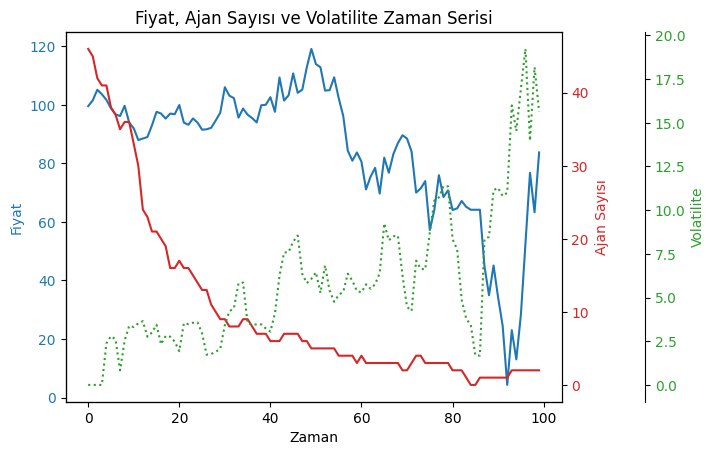

In [15]:
# VOLATILITEYİ DE GÖSTEREN GRAFİK

data = model.datacollector.get_model_vars_dataframe()

fig, ax1 = plt.subplots()

# Fiyat
ax1.set_xlabel("Zaman")
ax1.set_ylabel("Fiyat", color="tab:blue")
ax1.plot(data["Fiyat"], label="Fiyat", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Ajan Sayısı
ax2 = ax1.twinx()
ax2.set_ylabel("Ajan Sayısı", color="tab:red")
ax2.plot(data["AjanSayisi"], label="Ajan Sayısı", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Volatilite (3. eksen)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.set_ylabel("Volatilite", color="tab:green")
ax3.plot(data["Volatilite"], label="Volatilite", color="tab:green", linestyle="dotted")
ax3.tick_params(axis="y", labelcolor="tab:green")

plt.title("Fiyat, Ajan Sayısı ve Volatilite Zaman Serisi")
plt.show()


